# ⚽ Division FC - Match Analysis

Professional soccer visualizations with "Midnight Aurora" branding.

**Data Source:** StatsBomb Open Data (CC BY 4.0)

---

## ⚙️ Match Configuration

To analyze a different match, edit: `config/match_config.py`

## 1. Setup

In [1]:
# Add project root to path
import sys
from pathlib import Path

# Find project root
project_root = Path().absolute()
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print("✅ Setup complete!")


Project root: /workspaces/Division_FC
✅ Setup complete!


## 2. Load Match Data

Data is loaded from the **single source of truth** in `config/match_config.py`

In [2]:
# Import from unified config
from config.match_config import (
    get_match_data,
    get_home_team,
    get_away_team,
    COLORS,
    IMAGES_DIR,
    MATCH_CONFIG,
)

# Show current config
print("📋 Current Match Configuration:")
print(f"   Competition: {MATCH_CONFIG['competition_name']}")
print(f"   Season: {MATCH_CONFIG['season']}")
print(f"   Stage: {MATCH_CONFIG['stage']}")

# Load match data
print("\n📊 Loading match data...")
events, match_info = get_match_data()

📋 Current Match Configuration:
   Competition: FIFA World Cup
   Season: 2022
   Stage: Final

📊 Loading match data...
✅ Loaded: Argentina vs France
   Score: 3 - 3
   Date: 2022-12-18 00:00:00


## 3. View Goals

In [3]:
from src.data.loader import get_goals, get_display_name

# Get all goals
goals = get_goals(events)

print(f"⚽ Goals ({len(goals)} total):")
for _, goal in goals.iterrows():
    player = get_display_name(goal['player_name'])
    minute = int(goal['minute'])
    team = goal['team_name']
    print(f"   {minute}' - {player} ({team})")

⚽ Goals (12 total):
   22' - Messi (Argentina)
   35' - Di María (Argentina)
   79' - Mbappé (France)
   80' - Mbappé (France)
   107' - Messi (Argentina)
   117' - Mbappé (France)
   120' - Mbappé (France)
   121' - Messi (Argentina)
   122' - Dybala (Argentina)
   124' - Paredes (Argentina)
   125' - Muani (France)
   125' - Montiel (Argentina)


In [4]:
# Regulation time goals only
reg_goals = get_goals(events, regulation_only=True)

print(f"⚽ Regulation Time Goals ({len(reg_goals)} total):")
for _, goal in reg_goals.iterrows():
    player = get_display_name(goal['player_name'])
    minute = int(goal['minute'])
    team = goal['team_name']
    print(f"   {minute}' - {player} ({team})")

⚽ Regulation Time Goals (4 total):
   22' - Messi (Argentina)
   35' - Di María (Argentina)
   79' - Mbappé (France)
   80' - Mbappé (France)


## 4. View Top Players

In [5]:
from src.data.loader import get_top_players_by_stat

home_team = get_home_team()
away_team = get_away_team()

print("🎯 Top Shooters:")
home_shooters = get_top_players_by_stat(events, home_team, stat='shots', n=3)
away_shooters = get_top_players_by_stat(events, away_team, stat='shots', n=3)

print(f"   {home_team}: {[get_display_name(p) for p in home_shooters]}")
print(f"   {away_team}: {[get_display_name(p) for p in away_shooters]}")

print("\n👟 Most Touches:")
home_touches = get_top_players_by_stat(events, home_team, stat='touches', n=3)
away_touches = get_top_players_by_stat(events, away_team, stat='touches', n=3)

print(f"   {home_team}: {[get_display_name(p) for p in home_touches]}")
print(f"   {away_team}: {[get_display_name(p) for p in away_touches]}")

🎯 Top Shooters:
   Argentina: ['Messi', 'Martínez', 'Allister']
   France: ['Mbappé', 'Muani', 'Rabiot']

👟 Most Touches:
   Argentina: ['Fernandez', 'Messi', 'Paul']
   France: ['Koundé', 'Tchouaméni', 'Upamecano']


## 5. Run Full Analysis

Generate all visualizations and animations.

In [6]:
%run ../run_analysis.py

⚽ DIVISION FC - MATCH ANALYSIS

📊 Loading match data...

⚽ Goals:
   22' - Lionel Andrés Messi Cuccittini (Argentina)
   35' - Ángel Fabián Di María Hernández (Argentina)
   79' - Kylian Mbappé Lottin (France)
   80' - Kylian Mbappé Lottin (France)
   107' - Lionel Andrés Messi Cuccittini (Argentina)
   117' - Kylian Mbappé Lottin (France)
   120' - Kylian Mbappé Lottin (France)
   121' - Lionel Andrés Messi Cuccittini (Argentina)
   122' - Paulo Bruno Exequiel Dybala (Argentina)
   124' - Leandro Daniel Paredes (Argentina)
   125' - Randal Kolo Muani (France)
   125' - Gonzalo Ariel Montiel (Argentina)

🎯 Top Shooters:
   Argentina: ['Lionel Andrés Messi Cuccittini', 'Lautaro Javier Martínez']
   France: ['Kylian Mbappé Lottin', 'Randal Kolo Muani']

🎨 Creating visualizations...

   📍 Shot Maps:
   ✅ Saved: /workspaces/Division_FC/output/images/lionel_andres_messi_cuccittini_shots.png
   ✅ Saved: /workspaces/Division_FC/output/images/kylian_mbappe_lottin_shots.png

   🔥 Heatmaps:
   ✅

## 6. View Generated Images

In [7]:
from IPython.display import Image, display

# List generated files
print("📸 Generated images:")
for img in sorted(IMAGES_DIR.glob('*.png')):
    print(f"   - {img.name}")

📸 Generated images:
   - argentina_passes.png
   - custom_shot_map.png
   - france_passes.png
   - instagram_post.png
   - instagram_story.png
   - kylian_mbappe_lottin_heatmap.png
   - kylian_mbappe_lottin_shots.png
   - lionel_andres_messi_cuccittini_heatmap.png
   - lionel_andres_messi_cuccittini_shots.png
   - match_summary.png
   - zone_control.png


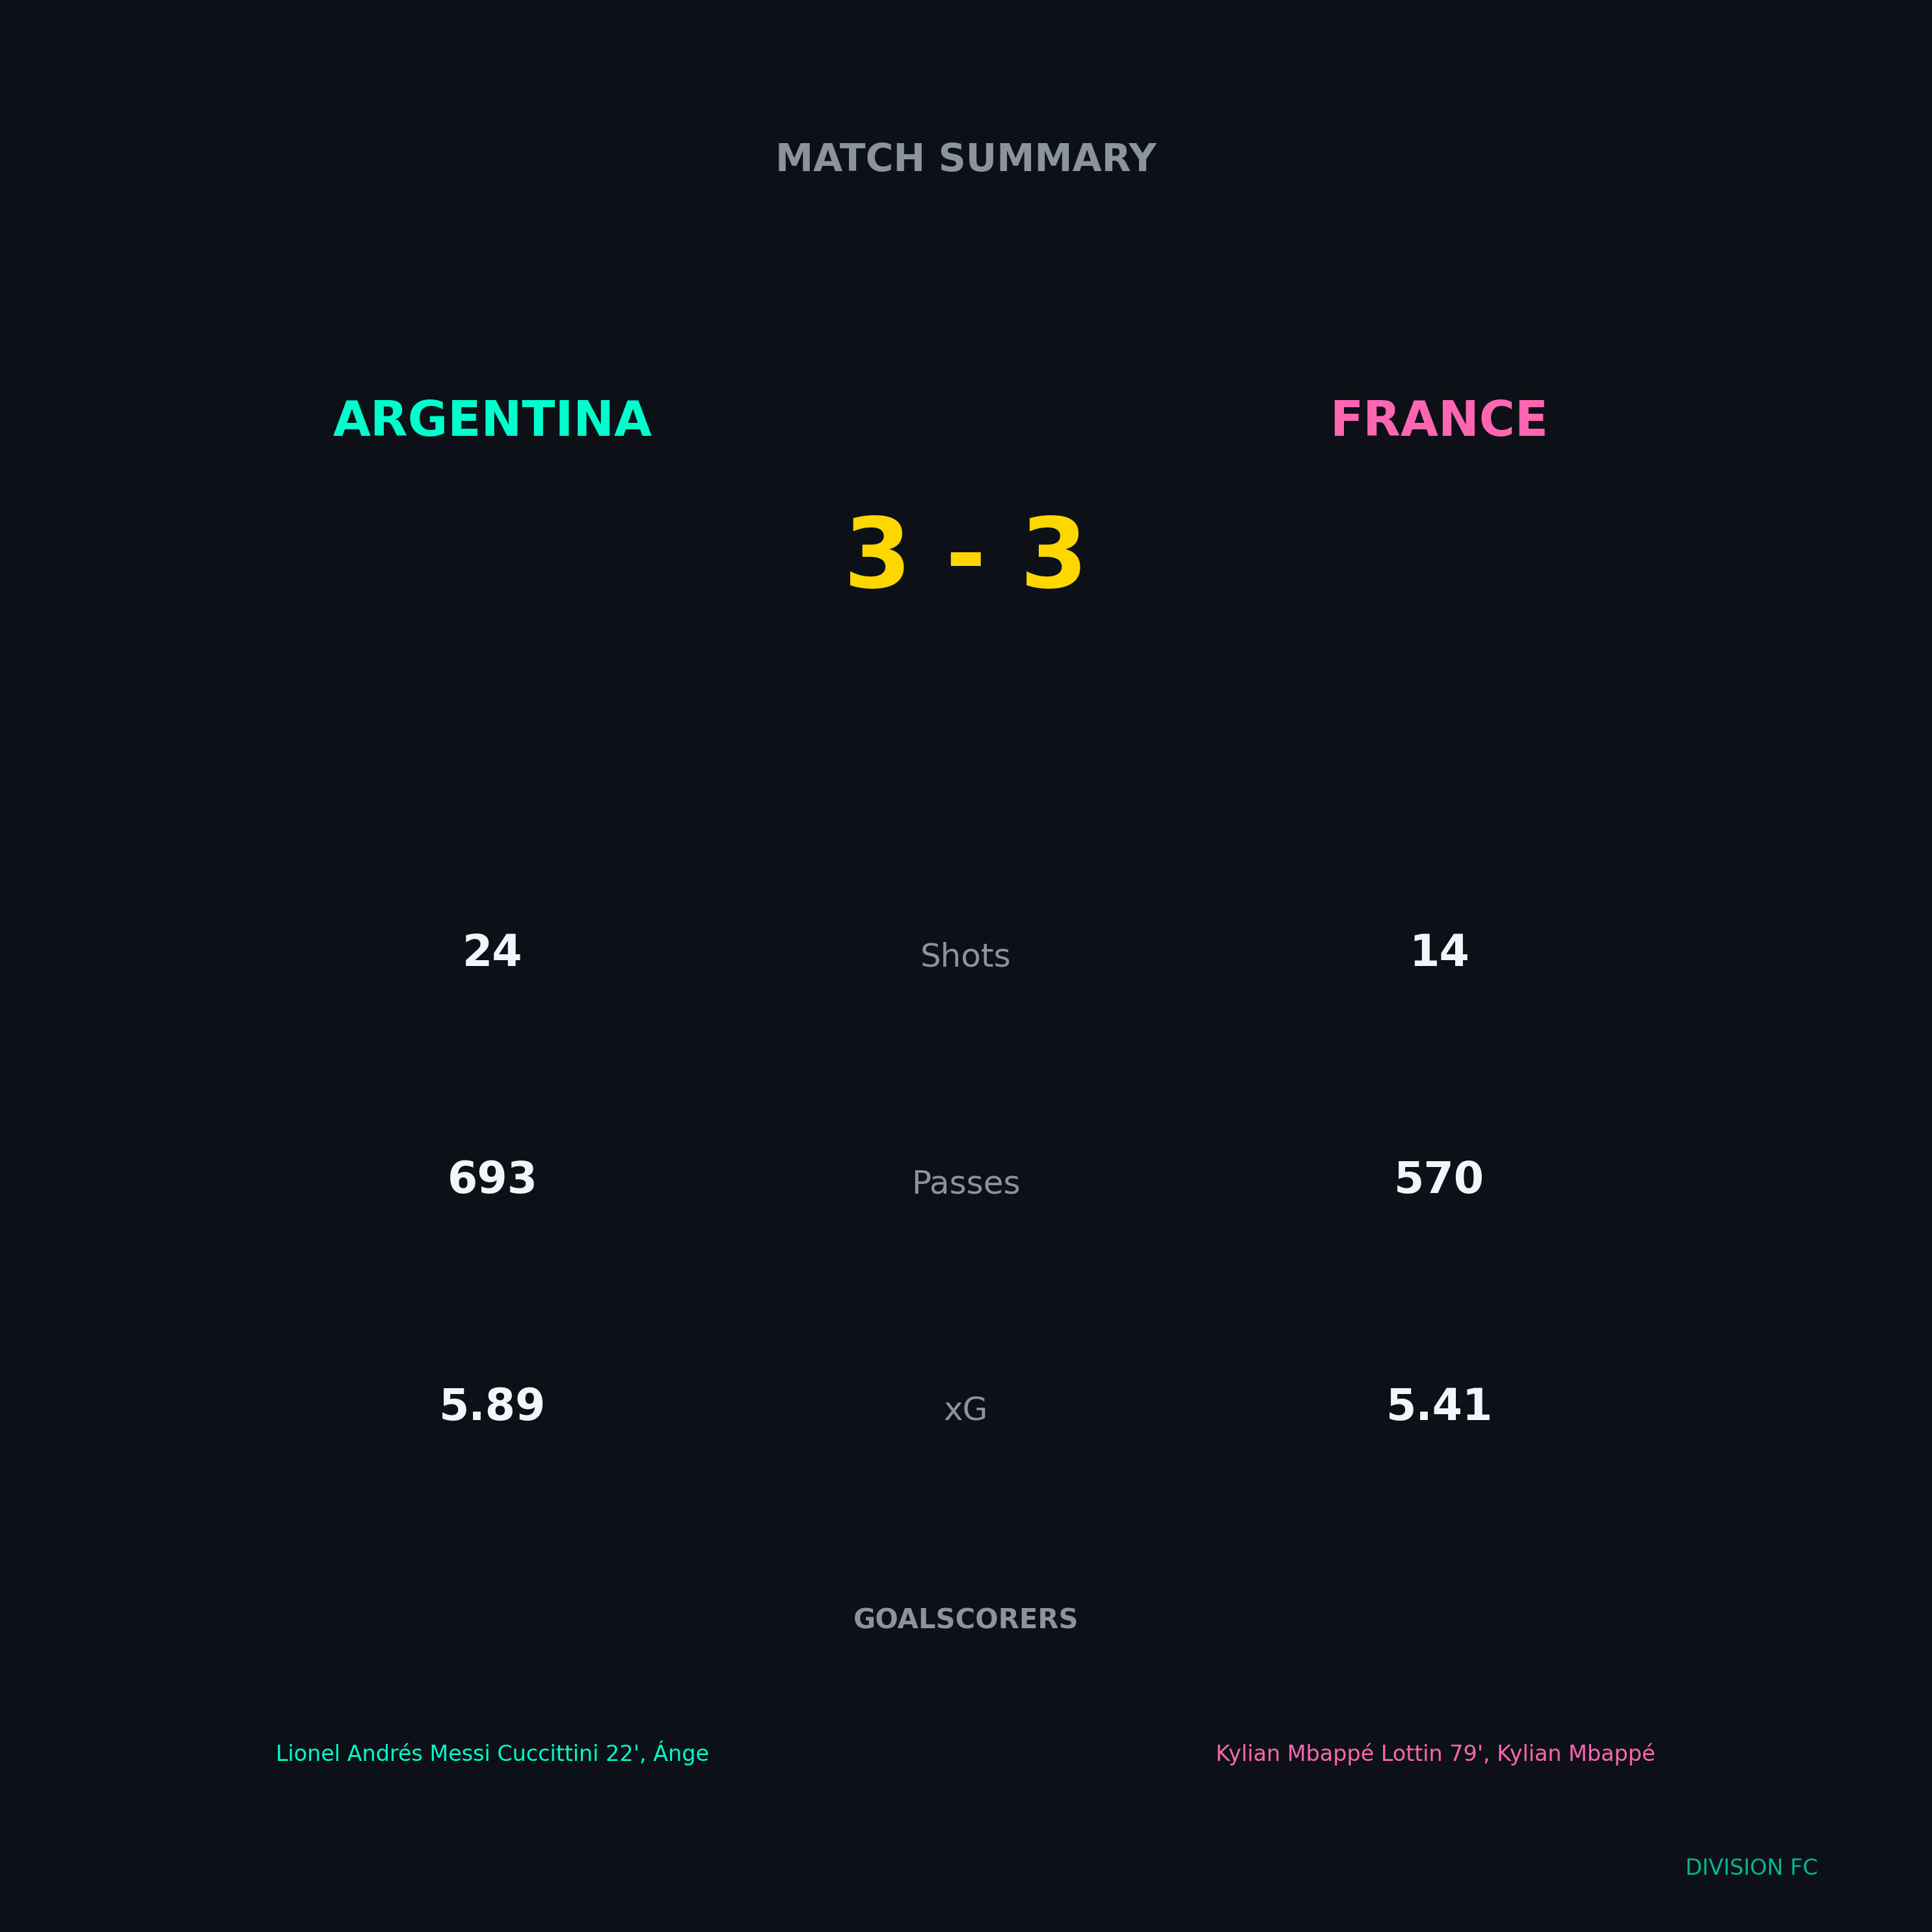

In [8]:
# Display match summary
display(Image(filename=str(IMAGES_DIR / 'match_summary.png'), width=500))

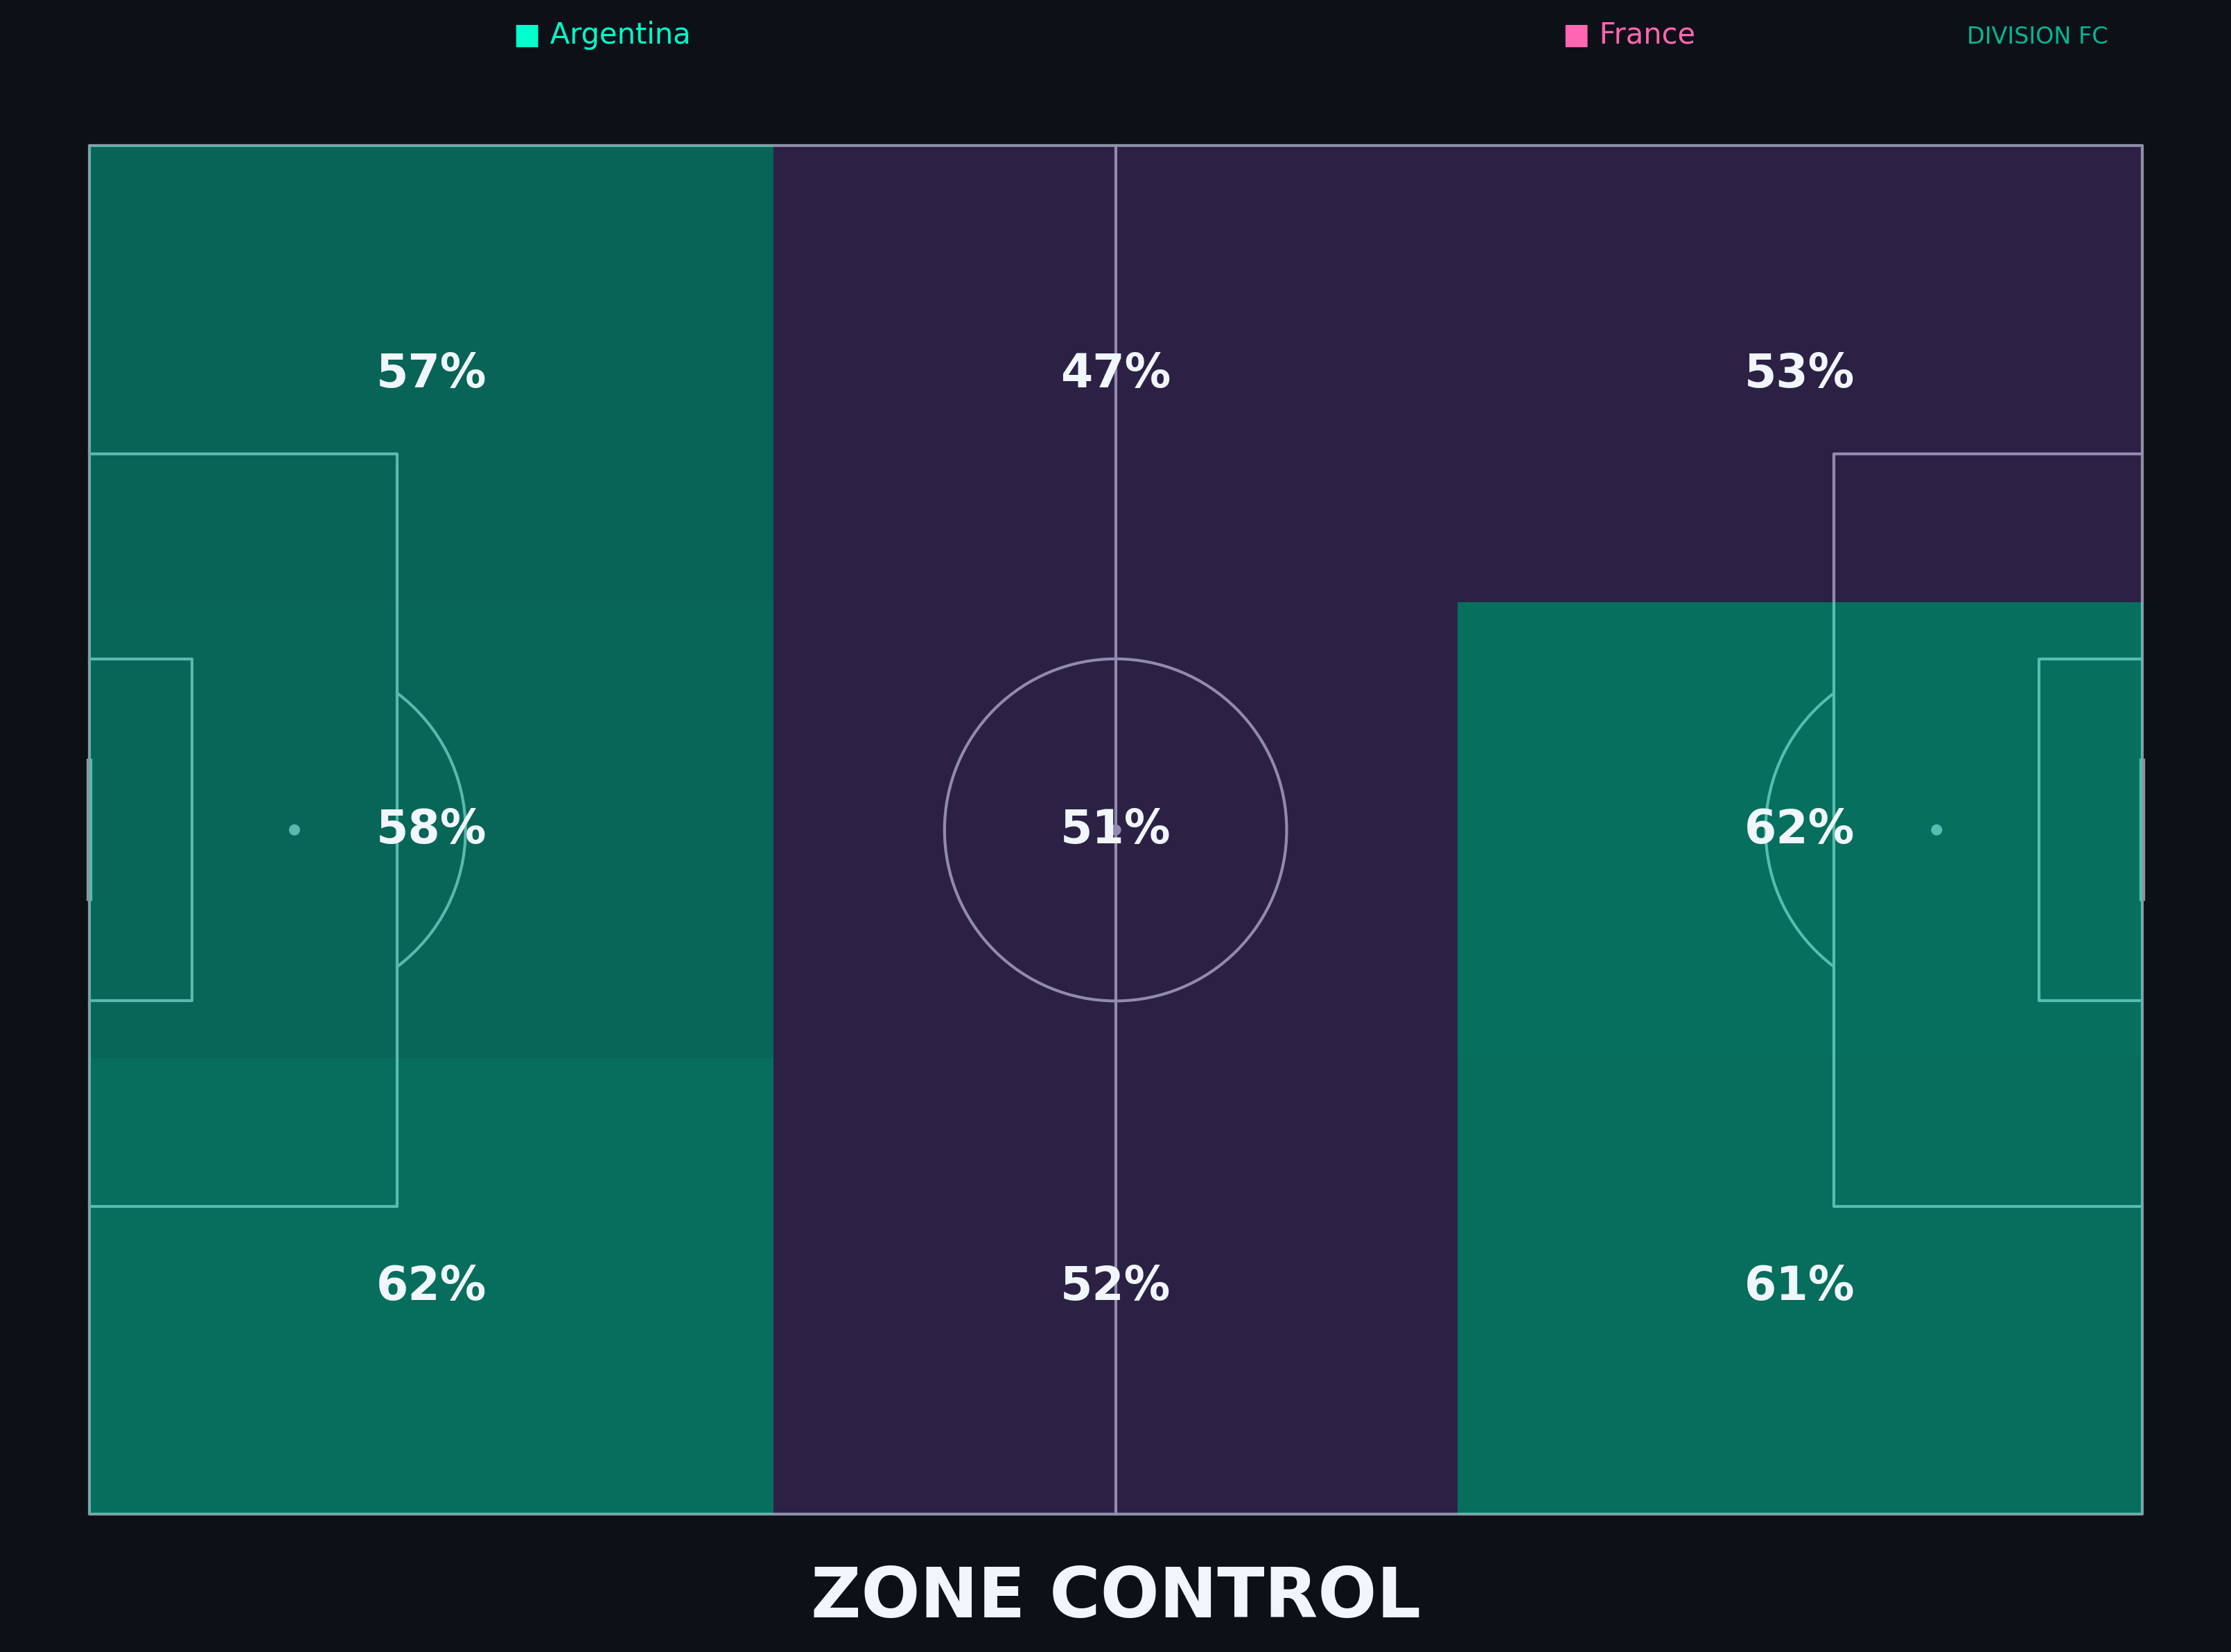

In [9]:
# Display zone control
display(Image(filename=str(IMAGES_DIR / 'zone_control.png'), width=600))

## 7. Create Custom Visualization

Creating shot map for Messi...
   ✅ Saved: /workspaces/Division_FC/output/images/custom_shot_map.png


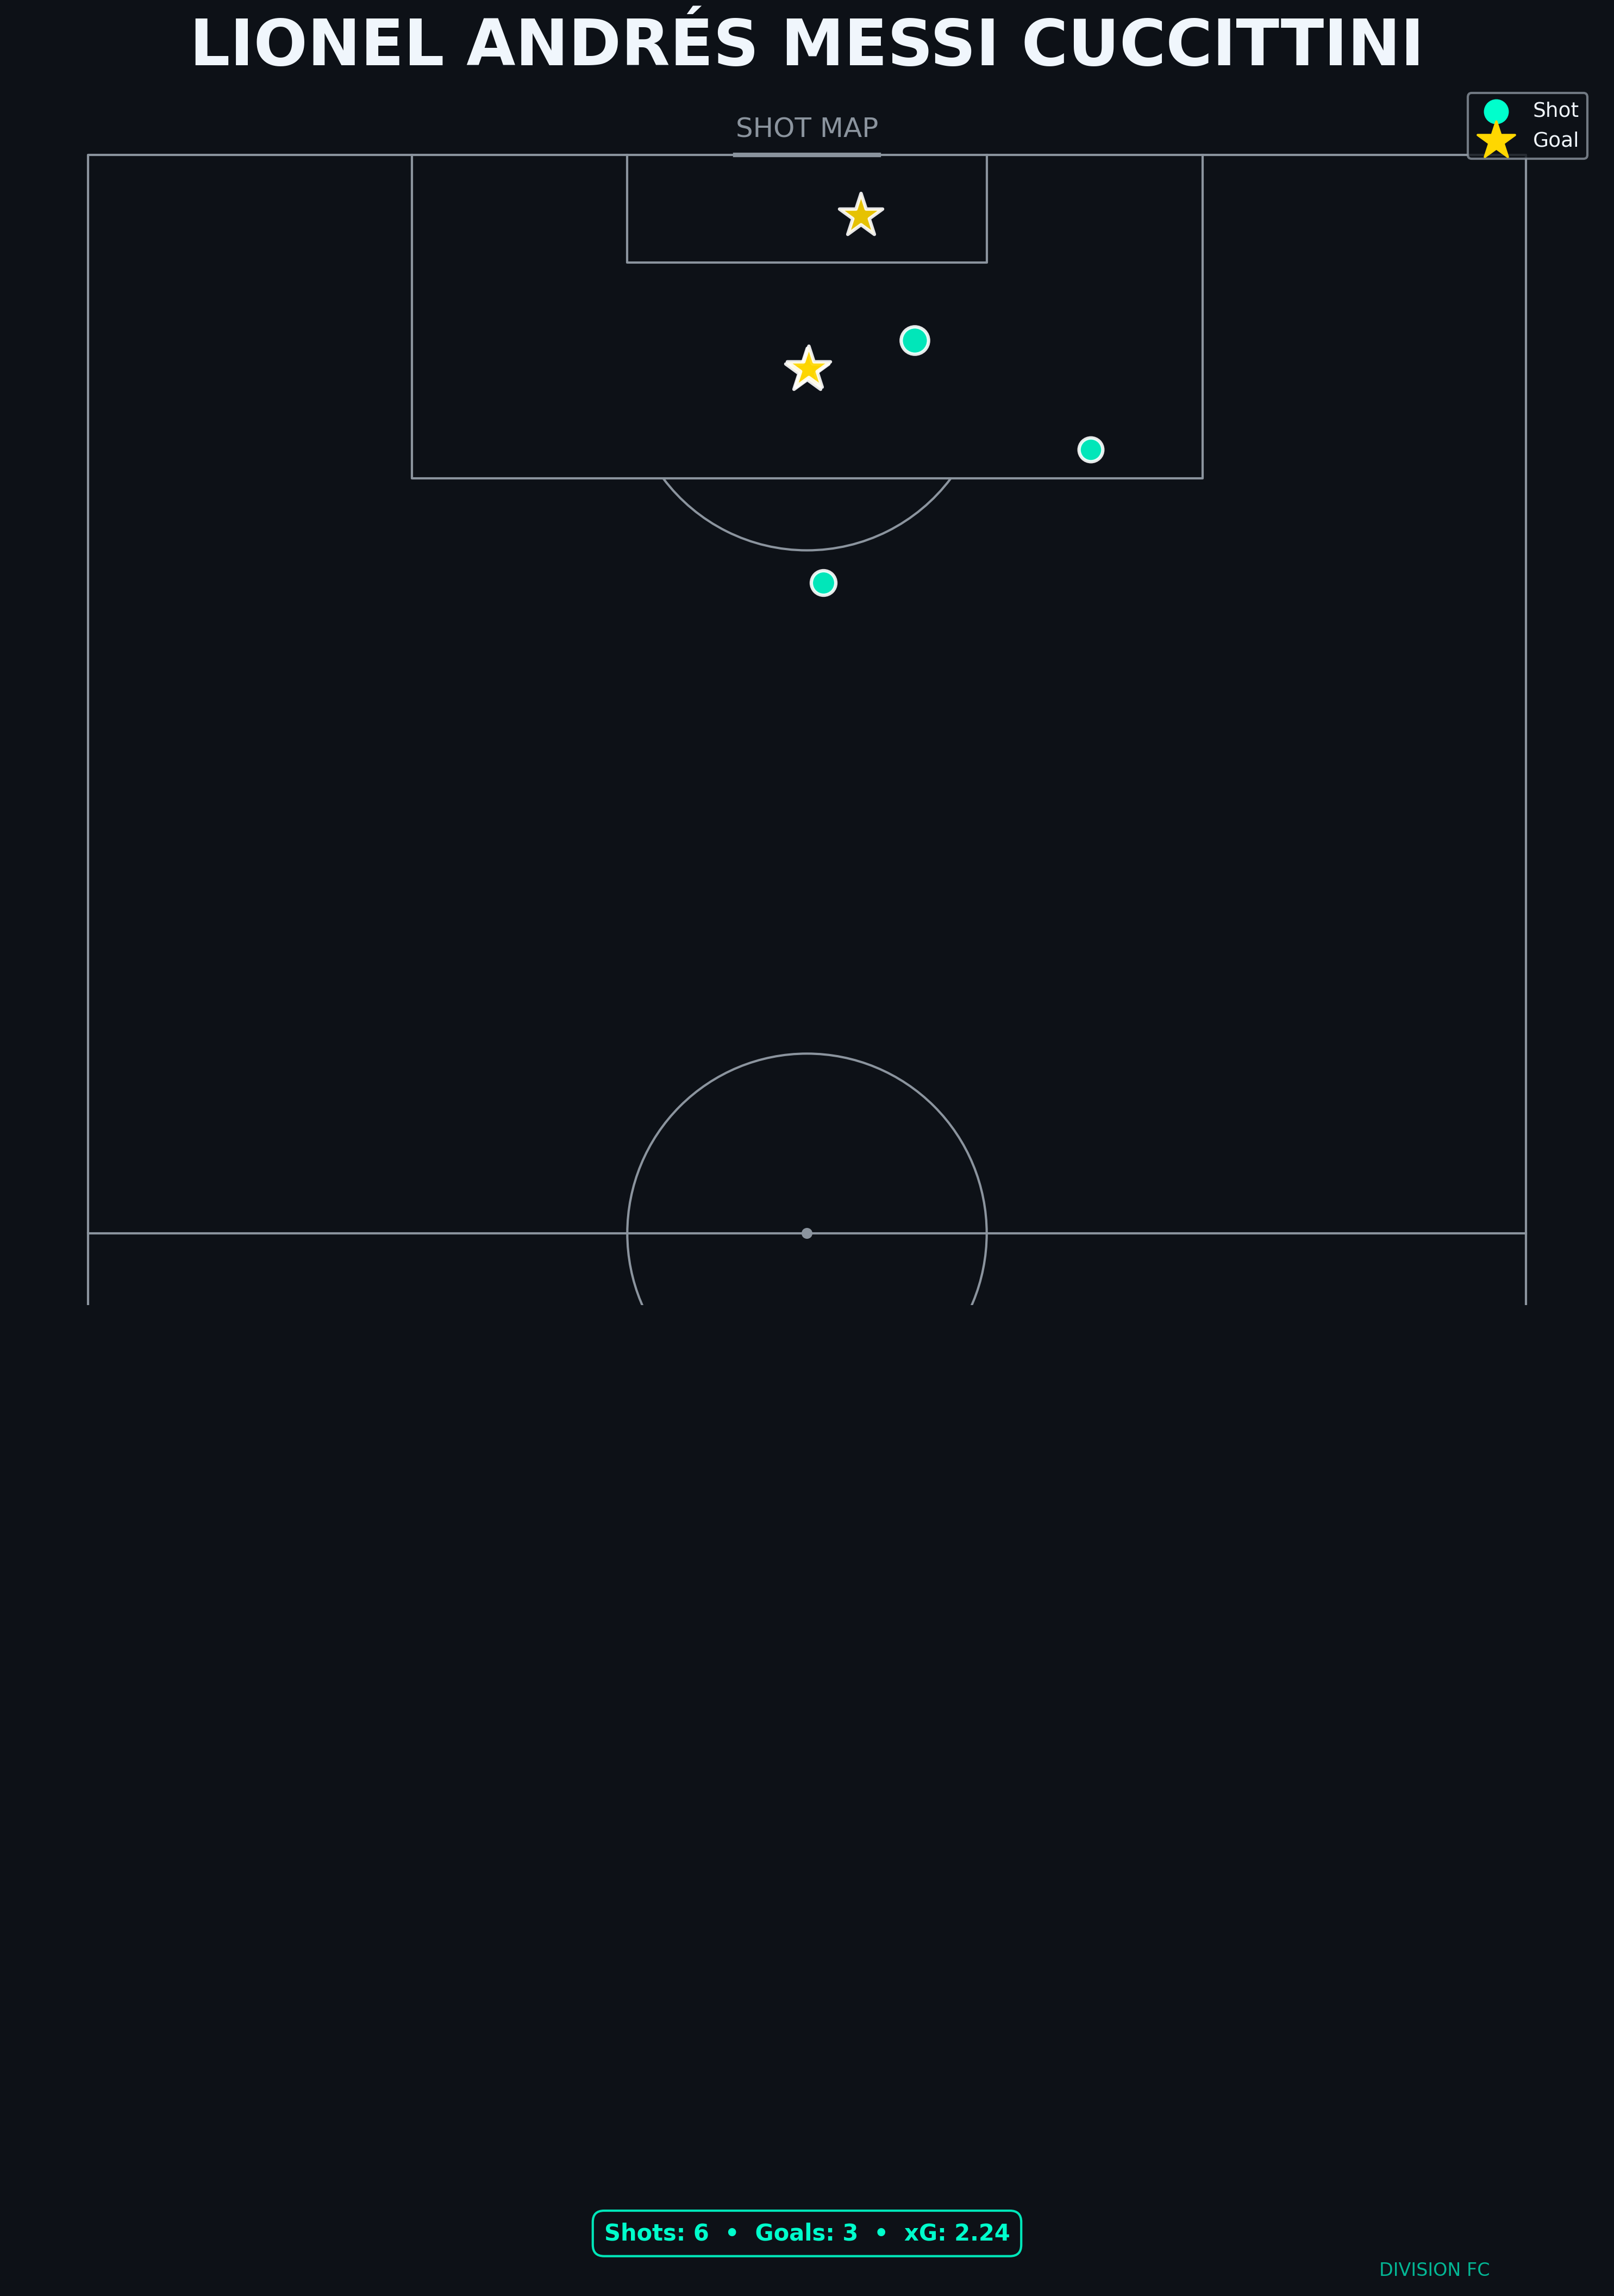

In [10]:
from run_analysis import create_shot_map, create_touch_heatmap

# Create shot map for a specific player
player = home_shooters[0]  # Top shooter
print(f"Creating shot map for {get_display_name(player)}...")
create_shot_map(events, player, 'custom_shot_map.png')

# Display it
display(Image(filename=str(IMAGES_DIR / 'custom_shot_map.png'), width=400))

## 8. Export for Instagram

In [11]:
from src.export.instagram import InstagramExporter
from PIL import Image as PILImage

exporter = InstagramExporter(output_dir=str(IMAGES_DIR.parent))

# Take an existing image and make it Instagram-ready
img = PILImage.open(IMAGES_DIR / 'match_summary.png')

# Square post (1080x1080)
post_img = exporter._resize_with_padding(img, (1080, 1080), COLORS['background'])
post_img = exporter._add_watermark(post_img, '@divisionfc')
post_img.save(IMAGES_DIR / 'instagram_post.png', 'PNG', quality=95)

# Story (1080x1920)
story_img = exporter._resize_with_padding(img, (1080, 1920), COLORS['background'])
story_img = exporter._add_watermark(story_img, '@divisionfc', position='bottom')
story_img.save(IMAGES_DIR / 'instagram_story.png', 'PNG', quality=95)

print("✅ Instagram exports saved!")
print(f"   Post: {IMAGES_DIR / 'instagram_post.png'}")
print(f"   Story: {IMAGES_DIR / 'instagram_story.png'}")

✅ Instagram exports saved!
   Post: /workspaces/Division_FC/output/images/instagram_post.png
   Story: /workspaces/Division_FC/output/images/instagram_story.png


In [12]:
# Create Goal Animation
import pandas as pd
from run_analysis import create_goal_animation
from src.data.loader import get_goals
from config.match_config import get_match_data, get_home_team, get_away_team, GIFS_DIR

events, match_info = get_match_data()
home_team = get_home_team()
away_team = get_away_team()

# Get all goals
goals = get_goals(events)

# Create animations for each team's first goal
home_goals = goals[goals['team_name'] == home_team]
away_goals = goals[goals['team_name'] == away_team]

print("🎬 Creating goal animations...")

if len(home_goals) > 0:
    goal_minute = int(home_goals.iloc[0]['minute'])
    create_goal_animation(events, goal_minute, home_team, f"{home_team.lower().replace(' ', '_')}_goal.gif")

if len(away_goals) > 0:
    goal_minute = int(away_goals.iloc[0]['minute'])
    create_goal_animation(events, goal_minute, away_team, f"{away_team.lower().replace(' ', '_')}_goal.gif")

print("✅ Animations saved to output/gifs/")

🎬 Creating goal animations...
   ✅ Saved: /workspaces/Division_FC/output/gifs/argentina_goal.gif
   ✅ Saved: /workspaces/Division_FC/output/gifs/france_goal.gif
✅ Animations saved to output/gifs/


🎬 Generated animations:
   - argentina_goal.gif


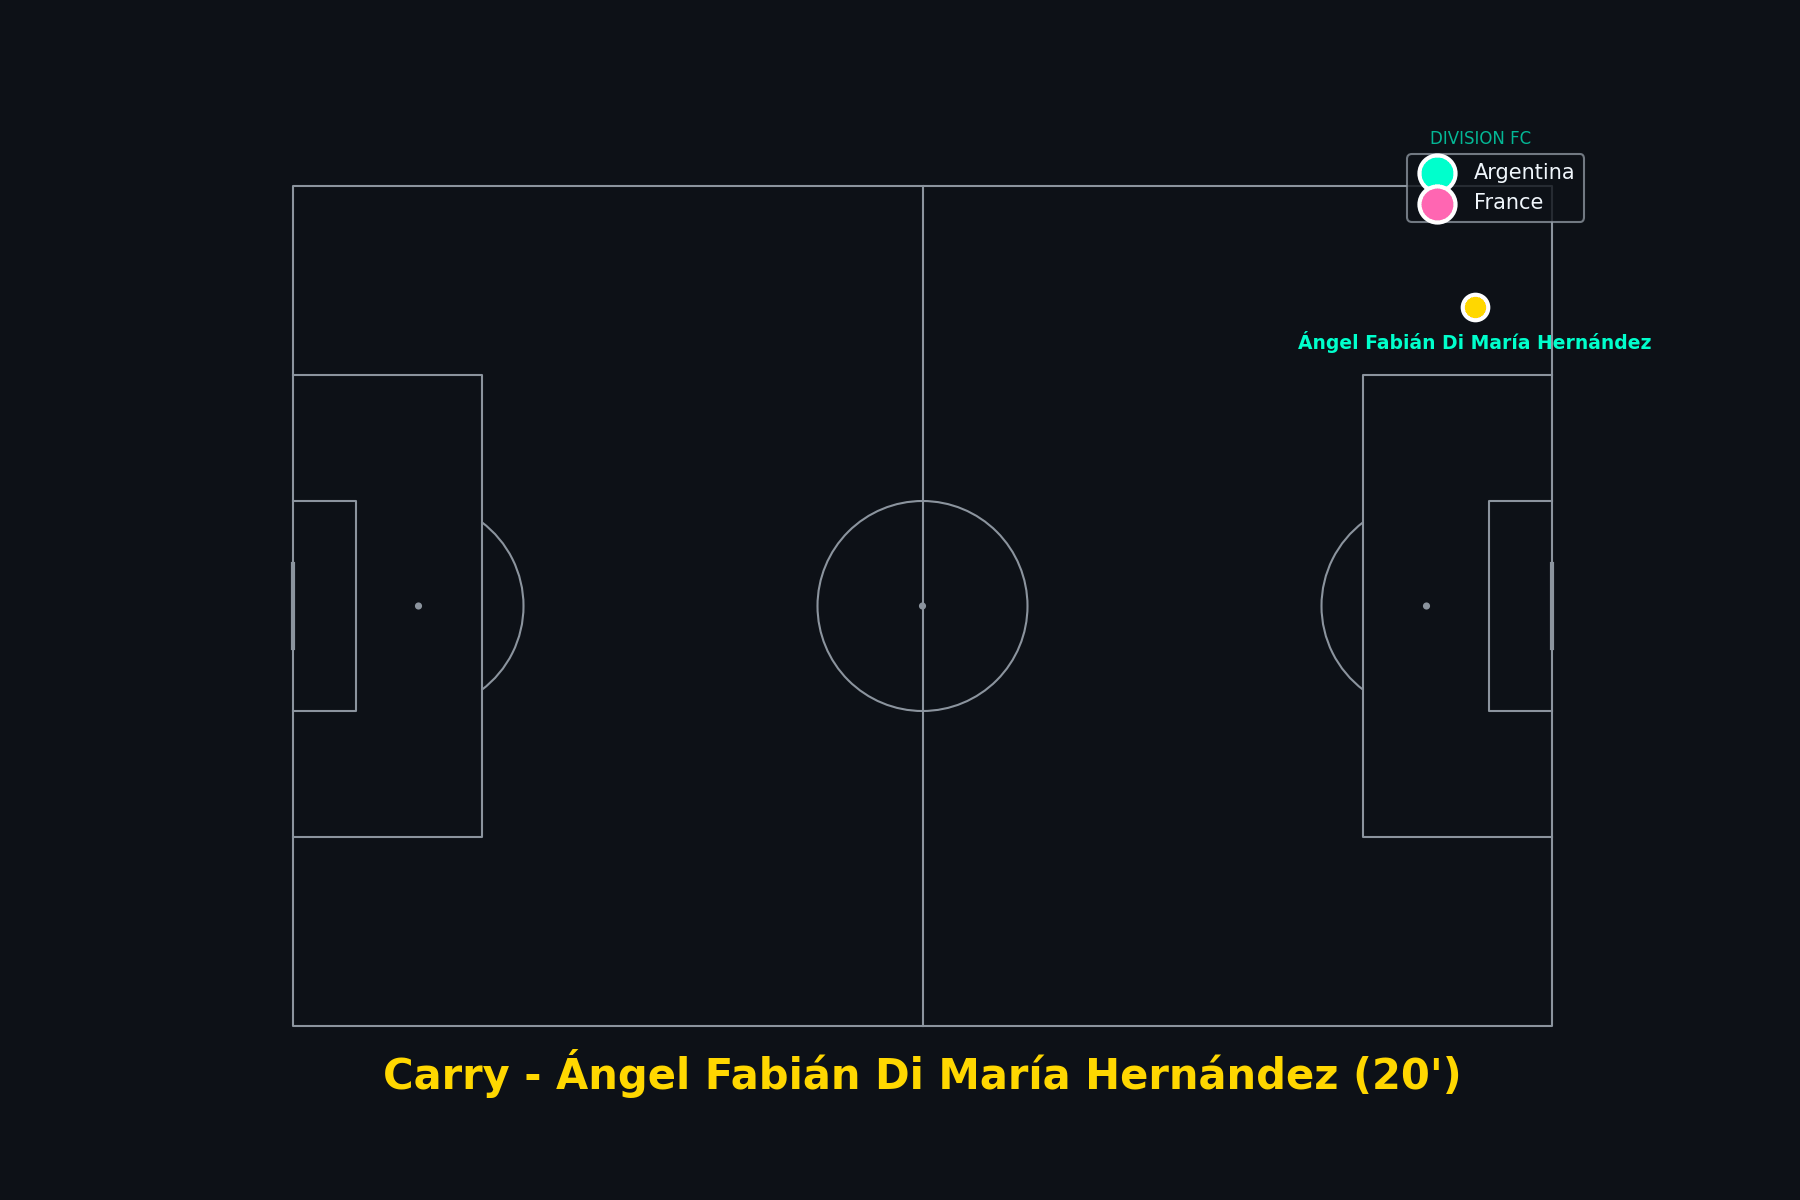

   - france_goal.gif


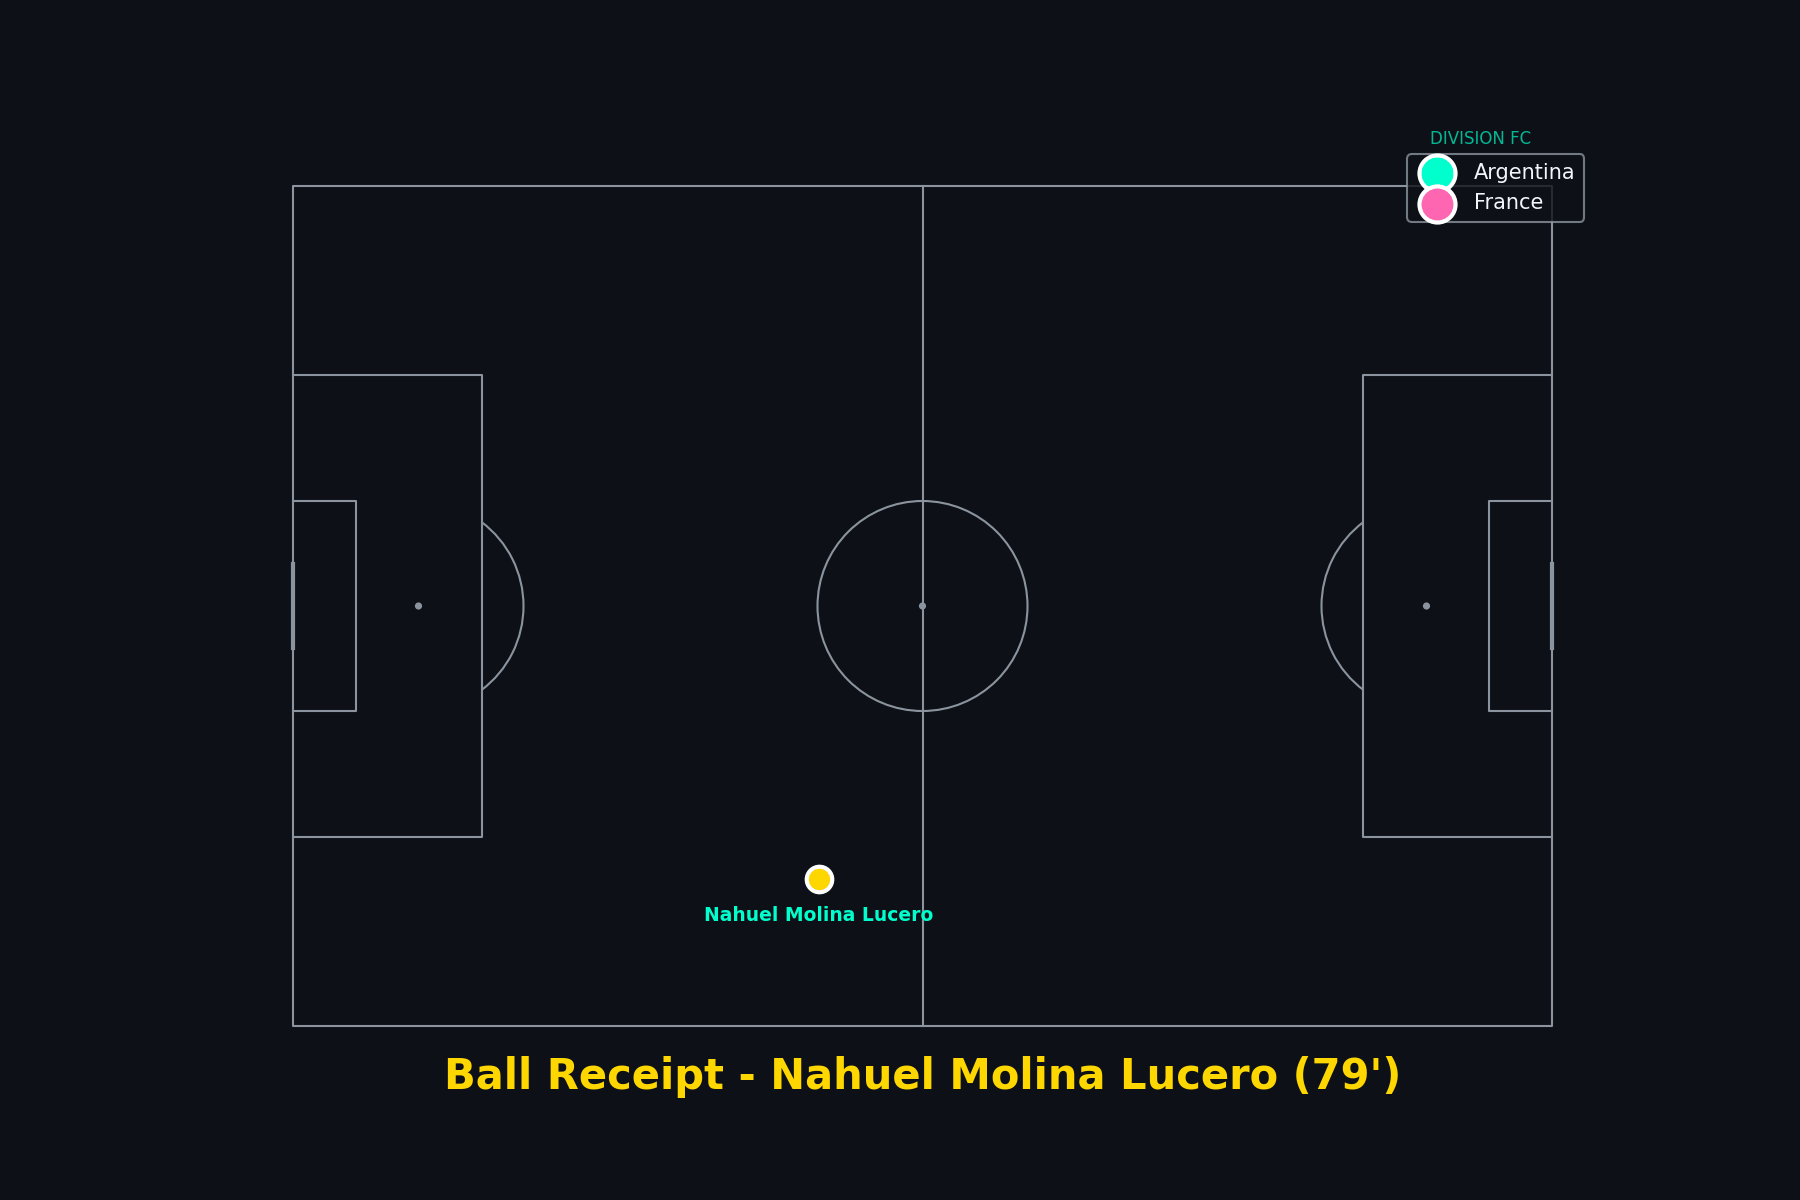

In [13]:
#Display Animation

from IPython.display import Image, display

# List generated GIFs
print("🎬 Generated animations:")
for gif in sorted(GIFS_DIR.glob('*.gif')):
    print(f"   - {gif.name}")
    display(Image(filename=str(gif), width=600))

   ✅ Saved: /workspaces/Division_FC/output/gifs/goal_23min.gif


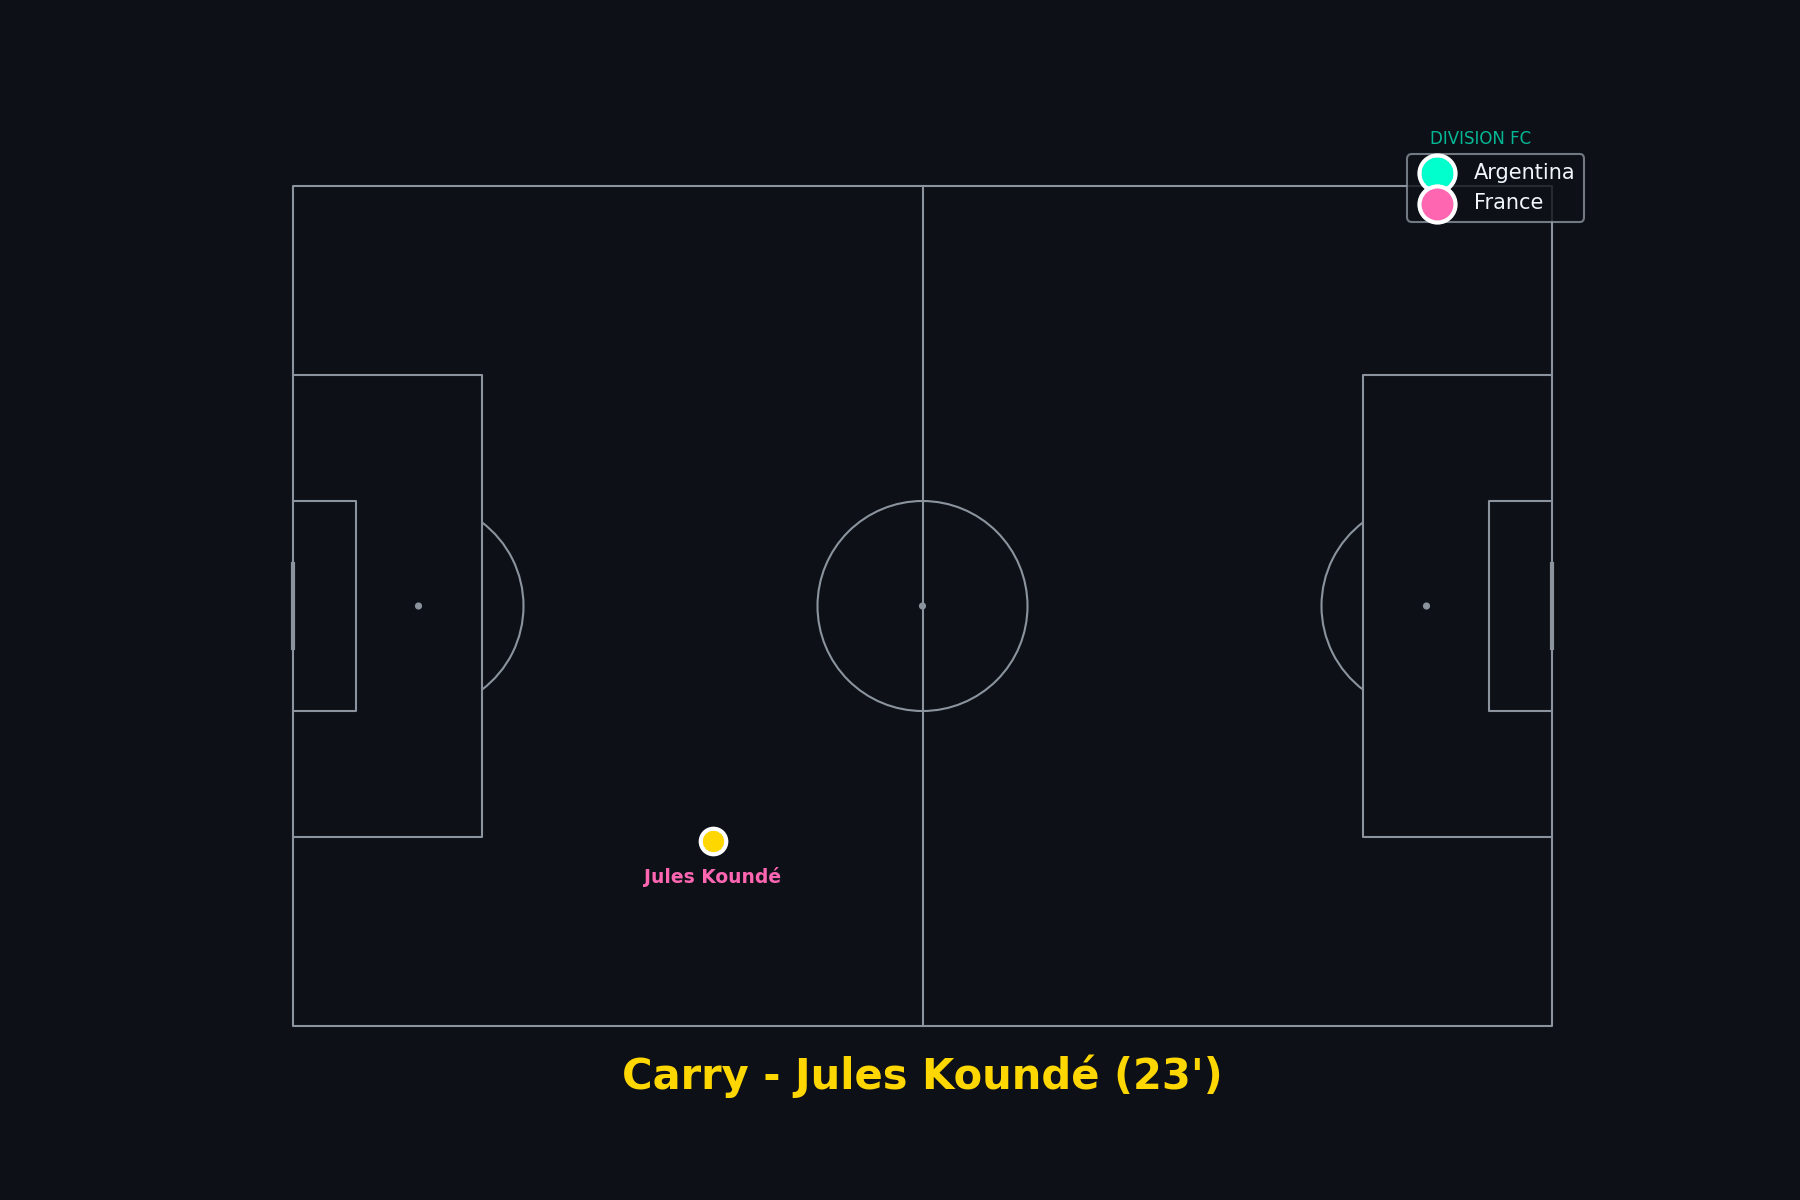

In [15]:
# Create animation for a specific goal minute
goal_minute = 23  # Change this to any goal minute
team = "Argentina"  # Change to the scoring team

create_goal_animation(events, goal_minute, team, f"goal_{goal_minute}min.gif")
display(Image(filename=str(GIFS_DIR / f"goal_{goal_minute}min.gif"), width=600))

---

## 📁 Output Files

All files saved to:
- `output/images/` - PNG visualizations
- `output/gifs/` - Animated GIFs

---

## 🙏 Credits

- **Data:** StatsBomb Open Data (CC BY 4.0)
- **Library:** mplsoccer by Andrew Rowlinson

---

*Division FC - Soccer Analytics* ⚽